# Ejercicio: Análisis de Regresión con el Dataset Wine Quality

## Descripción del Dataset

El dataset **Wine Quality** contiene resultados de análisis fisicoquímicos de vinos portugueses "Vinho Verde" y su calidad evaluada por expertos. El objetivo es predecir la calidad del vino basándose en sus propiedades químicas.

### Variables del dataset:
- **fixed acidity**: Acidez fija (g/L de ácido tartárico)
- **volatile acidity**: Acidez volátil (g/L de ácido acético)
- **citric acid**: Ácido cítrico (g/L)
- **residual sugar**: Azúcar residual (g/L)
- **chlorides**: Cloruros (g/L de cloruro de sodio)
- **free sulfur dioxide**: Dióxido de azufre libre (mg/L)
- **total sulfur dioxide**: Dióxido de azufre total (mg/L)
- **density**: Densidad (g/cm³)
- **pH**: pH del vino
- **sulphates**: Sulfatos (g/L de sulfato de potasio)
- **alcohol**: Contenido de alcohol (% vol)
- **quality**: Calidad del vino (puntuación de 0-10) - **Variable objetivo**

En este ejercicio, trabajarás con el dataset de vinos tintos y aplicarás diferentes técnicas de regresión para predecir la calidad del vino.

## 1. Importar librerías y cargar datos

In [18]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configurar seed para reproducibilidad
np.random.seed(42)

In [19]:
# Cargar el dataset de vinos tintos
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
wine_data = pd.read_csv(url, sep=';')

print("Dataset cargado exitosamente!")
print(f"Dimensiones del dataset: {wine_data.shape}")
print(f"\nColumnas del dataset:")
print(wine_data.columns.tolist())

Dataset cargado exitosamente!
Dimensiones del dataset: (1599, 12)

Columnas del dataset:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


## 2. Análisis Exploratorio de Datos (EDA)

### Ejercicio 2.1: Exploración inicial
Completa el análisis exploratorio inicial del dataset.

In [20]:
# Mostrar las primeras filas del dataset
wine_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [21]:
# TODO: Muestra la información general del dataset (tipos de datos, valores no nulos)
# Tu código aquí
wine_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [22]:
# TODO: Calcula y muestra las estadísticas descriptivas del dataset
# Tu código aquí
wine_data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [7]:
# TODO: Verifica si hay valores nulos en el dataset
# Tu código aquí
wine_data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

### Ejercicio 2.2: Análisis de la variable objetivo

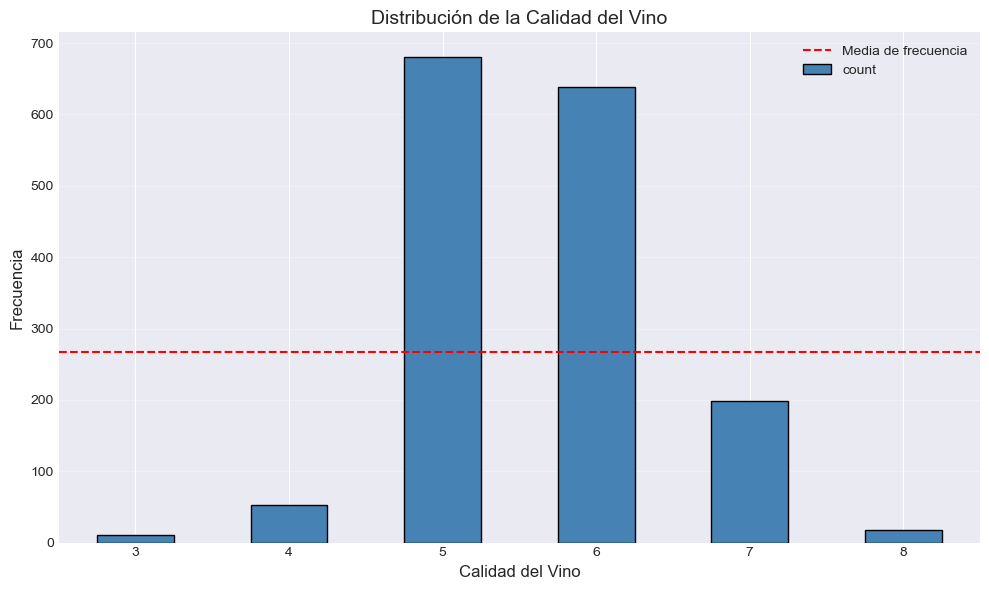

Estadísticas de la calidad del vino:
Media: 5.64
Mediana: 6.00
Desviación estándar: 0.81


In [23]:
# Analizar la distribución de la calidad del vino
plt.figure(figsize=(10, 6))
wine_data['quality'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Calidad del Vino', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución de la Calidad del Vino', fontsize=14)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Agregar estadísticas
mean_quality = wine_data['quality'].mean()
median_quality = wine_data['quality'].median()
plt.axhline(y=wine_data['quality'].value_counts().mean(), color='red', 
            linestyle='--', label=f'Media de frecuencia')

plt.legend()
plt.tight_layout()
plt.show()

print(f"Estadísticas de la calidad del vino:")
print(f"Media: {mean_quality:.2f}")
print(f"Mediana: {median_quality:.2f}")
print(f"Desviación estándar: {wine_data['quality'].std():.2f}")

### Ejercicio 2.3: Matriz de correlación

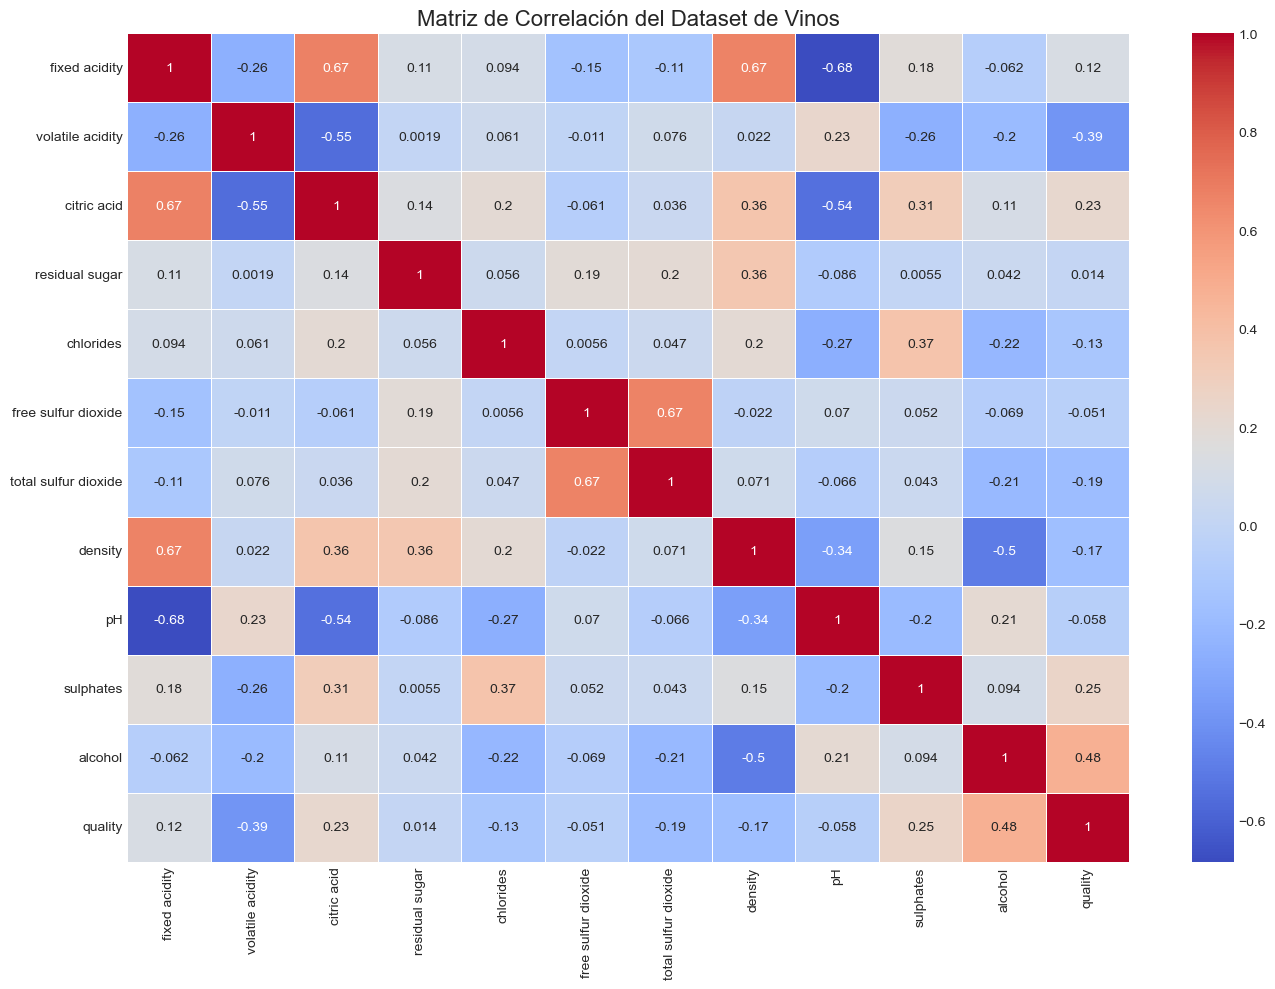

In [24]:
# TODO: Calcula la matriz de correlación y visualízala con un heatmap
# Pista: Usa sns.heatmap() con annot=True para mostrar los valores
# Tu código aquí

plt.figure(figsize=(14, 10))
# Completa el código para crear el heatmap
sns.heatmap(wine_data.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación del Dataset de Vinos', fontsize=16)
plt.tight_layout()
plt.show()

In [25]:
# TODO: Identifica y muestra las 5 variables más correlacionadas con 'quality'
# Tu código aquí
correlation_matrix = wine_data.corr()
correlation_with_quality = correlation_matrix['quality'].drop('quality')
top_5_correlated = correlation_with_quality.abs().sort_values(ascending=False).head(5)
print("Las 5 variables más correlacionadas con 'quality':")
print(top_5_correlated)


Las 5 variables más correlacionadas con 'quality':
alcohol                 0.476166
volatile acidity        0.390558
sulphates               0.251397
citric acid             0.226373
total sulfur dioxide    0.185100
Name: quality, dtype: float64


### Ejercicio 2.4: Visualización de relaciones

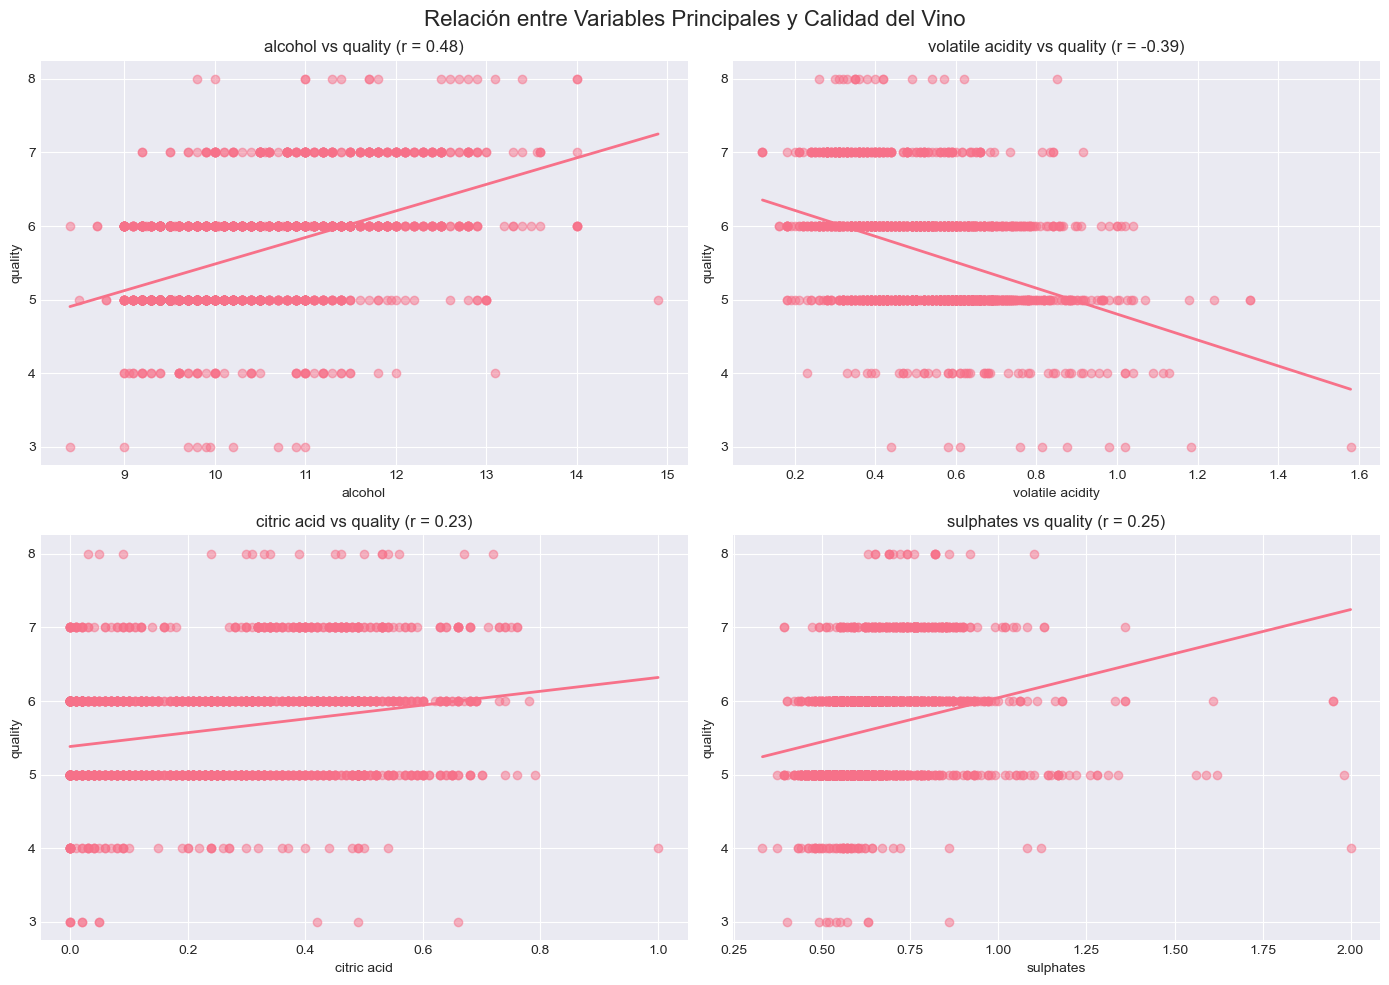

In [26]:
# Visualizar las 4 variables más correlacionadas con quality
top_features = ['alcohol', 'volatile acidity', 'citric acid', 'sulphates']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Relación entre Variables Principales y Calidad del Vino', fontsize=16)

for idx, (ax, feature) in enumerate(zip(axes.flat, top_features)):
    # TODO: Crea un scatter plot para cada variable vs quality
    # 1) Extraer datos
    x = wine_data[feature].values
    y = wine_data['quality'].values
    ax.scatter(x, y, alpha=0.5)
    # Agrega una línea de tendencia
    m, b = np.polyfit(x, y, deg=1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = m * x_line + b
    ax.plot(x_line, y_line, linewidth=2)
    # 5) Etiquetas y título con r
    r = np.corrcoef(x, y)[0, 1]
    ax.set_xlabel(feature)
    ax.set_ylabel('quality')
    ax.set_title(f'{feature} vs quality (r = {r:.2f})')
    

plt.tight_layout()
plt.show()

## 3. Preparación de Datos

In [27]:
# Separar características (X) y variable objetivo (y)
X = wine_data.drop('quality', axis=1)
y = wine_data['quality']

print(f"Forma de X: {X.shape}")
print(f"Forma de y: {y.shape}")
print(f"\nCaracterísticas: {X.columns.tolist()}")

Forma de X: (1599, 11)
Forma de y: (1599,)

Características: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [28]:
# TODO: Divide los datos en conjuntos de entrenamiento y prueba
# Usa test_size=0.2 y random_state=42
# Tu código aquí
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")
print(f"Tamaño del conjunto de entrenamiento: {y_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {y_test.shape[0]} muestras")

# Pa ver si jala todo chido
assert X_train.shape[0] + X_test.shape[0] == X.shape[0]
assert y_train.shape[0] + y_test.shape[0] == y.shape[0]

Tamaño del conjunto de entrenamiento: 1279 muestras
Tamaño del conjunto de prueba: 320 muestras
Tamaño del conjunto de entrenamiento: 1279 muestras
Tamaño del conjunto de prueba: 320 muestras


In [29]:
# TODO: Estandariza las características
# Recuerda: ajusta el scaler solo con los datos de entrenamiento
# Tu código aquí

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 4. Validación Cruzada para Selección de Hiperparámetros

La validación cruzada es fundamental para seleccionar los mejores hiperparámetros sin usar el conjunto de prueba.

### Ejercicio 4.1: Implementación manual de validación cruzada

In [31]:
# Ejemplo: Validación cruzada manual para Ridge
def manual_cross_validation(X, y, alpha, n_folds=5):
    """
    Implementa validación cruzada manualmente para Ridge regression
    """
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in kf.split(X):
        # Dividir datos
        X_train_cv = X.iloc[train_idx]
        X_val_cv   = X.iloc[val_idx]
        y_train_cv = y[train_idx]
        y_val_cv   = y[val_idx]
        
        # Estandarizar
        scaler_cv = StandardScaler()
        X_train_cv_scaled = scaler_cv.fit_transform(X_train_cv)
        X_val_cv_scaled = scaler_cv.transform(X_val_cv)
        
        # Entrenar modelo
        model = Ridge(alpha=alpha)
        model.fit(X_train_cv_scaled, y_train_cv)
        
        # Evaluar
        y_pred = model.predict(X_val_cv_scaled)
        rmse = np.sqrt(mean_squared_error(y_val_cv, y_pred))
        scores.append(rmse)
    
    return np.mean(scores), np.std(scores)

# Probar diferentes valores de alpha
alphas_to_test = [0.001, 0.01, 0.1, 1, 10, 100]
cv_results_manual = []

print("Validación Cruzada Manual para Ridge Regression:")
print("-" * 50)

# Reset index to ensure integer indexing for KFold
X_train_reset = X_train.reset_index(drop=True)
y_train_reset = y_train.reset_index(drop=True)

for alpha in alphas_to_test:
    mean_rmse, std_rmse = manual_cross_validation(X_train_reset, y_train_reset, alpha)
    cv_results_manual.append({'alpha': alpha, 'mean_rmse': mean_rmse, 'std_rmse': std_rmse})
    print(f"Alpha: {alpha:7.3f} | RMSE: {mean_rmse:.4f} (+/- {std_rmse:.4f})")

# TODO: Identifica el mejor alpha basado en el RMSE medio más bajo
# Tu código aquí


Validación Cruzada Manual para Ridge Regression:
--------------------------------------------------
Alpha:   0.001 | RMSE: 0.6618 (+/- 0.0136)
Alpha:   0.010 | RMSE: 0.6618 (+/- 0.0136)
Alpha:   0.100 | RMSE: 0.6618 (+/- 0.0136)
Alpha:   1.000 | RMSE: 0.6617 (+/- 0.0136)
Alpha:  10.000 | RMSE: 0.6612 (+/- 0.0135)
Alpha: 100.000 | RMSE: 0.6599 (+/- 0.0139)


### Ejercicio 4.2: Usar RidgeCV para validación cruzada automática

In [ ]:
# TODO: Usa RidgeCV para encontrar automáticamente el mejor alpha
# Pista: RidgeCV tiene un parámetro 'alphas' y 'cv'
# Tu código aquí

from sklearn.pipeline import make_pipeline


alphas = np.logspace(-3, 3, 100)  # 100 valores entre 0.001 y 1000
cv = KFold(n_splits=5, shuffle=True, random_state=42)
model = make_pipeline(StandardScaler(), RidgeCV(alphas=alphas, scoring='neg_mean_squared_error', cv=cv))
model.fit(X_train, y_train)
best_alpha = model.named_steps['ridgecv'].alpha_
print(f"Mejor alpha encontrado por RidgeCV: {best_alpha}")


Mejor alpha encontrado por RidgeCV: 93.26033468832199


### Ejercicio 4.3: GridSearchCV para búsqueda exhaustiva

In [33]:
# Ejemplo completo con GridSearchCV para Ridge
from matplotlib.pyplot import grid
from sklearn.model_selection import GridSearchCV

# Definir parámetros a buscar
param_grid_ridge = {
    'alpha': np.logspace(-3, 3, 20)  # 20 valores entre 0.001 y 1000
}

# Crear modelo base
ridge_base = Ridge(random_state=42)

# TODO: Implementa GridSearchCV
# Usa cv=5, scoring='neg_mean_squared_error'
# Tu código aquí

grid_search_ridge = GridSearchCV(estimator=ridge_base, param_grid=param_grid_ridge,
                                 scoring='neg_mean_squared_error', cv=5, n_jobs=-1)
grid_search_ridge.fit(X_train_scaled, y_train)

best_alpha = grid_search_ridge.best_params_['alpha']
best_rmse_cv = (-grid_search_ridge.best_score_) ** 0.5
print(f"Mejor alpha: {best_alpha}")
print(f"Mejor score (RMSE CV): {best_rmse_cv:.4f}")

Mejor alpha: 54.555947811685144
Mejor score (RMSE CV): 0.6624


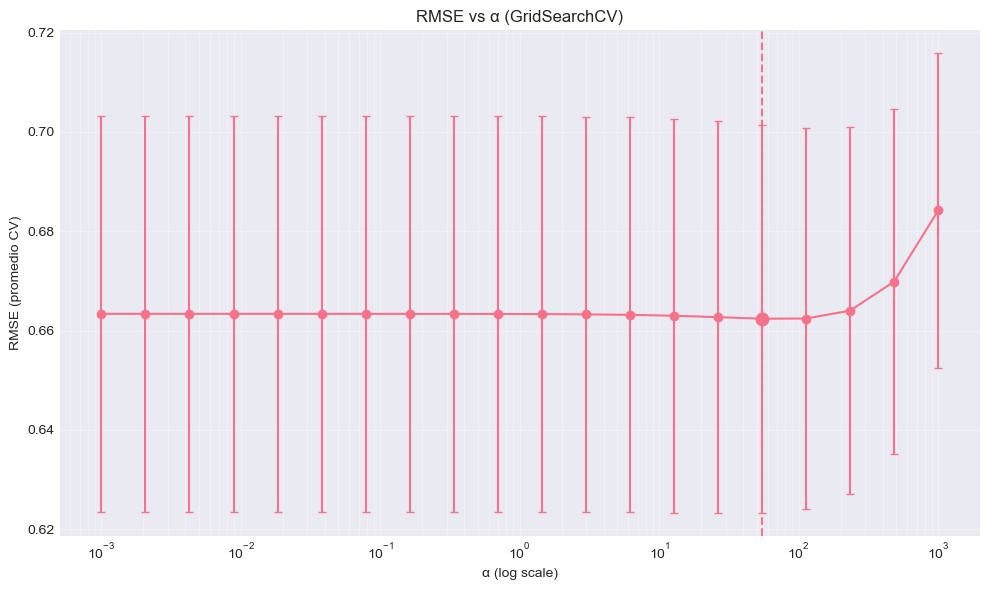

Mejor α (GridSearchCV): 54.555947811685144 | RMSE CV: 0.6624


In [35]:
# TODO: Visualiza los resultados de la validación cruzada
# Crea un gráfico que muestre cómo cambia el RMSE con diferentes valores de alpha
# Tu código aquí

plt.figure(figsize=(10, 6))
cvres = pd.DataFrame(grid_search_ridge.cv_results_)

# Detectar el nombre de la columna de alpha según el pipeline usado
alpha_col = 'param_alpha' if 'param_alpha' in cvres.columns else 'param_ridge__alpha'

alphas    = cvres[alpha_col].astype(float).values
mse_mean  = -cvres['mean_test_score'].values           # GridSearch usa MSE negativo
rmse_mean = np.sqrt(mse_mean)

# Aproximación del desvío de RMSE a partir del desvío de MSE (delta method)
mse_std   = cvres['std_test_score'].values
rmse_std  = mse_std / (2*np.sqrt(mse_mean))

# Ordenar por alpha para trazar una curva limpia
order = np.argsort(alphas)
alphas_ord, rmse_mean_ord, rmse_std_ord = alphas[order], rmse_mean[order], rmse_std[order]

plt.errorbar(
    alphas_ord,
    rmse_mean_ord,
    yerr=rmse_std_ord,
    fmt='o-',
    capsize=3
)

plt.xscale('log')

# Línea vertical en el mejor alpha
best_alpha = grid_search_ridge.best_params_['alpha']
best_rmse  = np.sqrt(-grid_search_ridge.best_score_)
plt.axvline(best_alpha, linestyle='--')
plt.scatter([best_alpha], [best_rmse], s=80)

plt.title('RMSE vs α (GridSearchCV)')
plt.xlabel('α (log scale)')
plt.ylabel('RMSE (promedio CV)')
plt.grid(True, which='both', axis='both', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mejor α (GridSearchCV): {best_alpha} | RMSE CV: {best_rmse:.4f}")


## 5. Modelos de Regresión

### 5.1 Regresión Lineal Normal

In [36]:
# TODO: Implementa y entrena un modelo de regresión lineal
# Tu código aquí

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Hacer predicciones
y_pred_lr_train = lr_model.predict(X_train_scaled)
y_pred_lr_test = lr_model.predict(X_test_scaled)

# Calcular métricas
rmse_lr_train = np.sqrt(mean_squared_error(y_train, y_pred_lr_train))
rmse_lr_test = np.sqrt(mean_squared_error(y_test, y_pred_lr_test))
r2_lr_train = r2_score(y_train, y_pred_lr_train)
r2_lr_test = r2_score(y_test, y_pred_lr_test)


print("Regresión Lineal Normal:")
print(f"RMSE Train: {rmse_lr_train:.4f}")
print(f"RMSE Test: {rmse_lr_test:.4f}")
print(f"R² Train: {r2_lr_train:.4f}")
print(f"R² Test: {r2_lr_test:.4f}")

Regresión Lineal Normal:
RMSE Train: 0.6513
RMSE Test: 0.6245
R² Train: 0.3480
R² Test: 0.4032


### 5.2 Ridge Regression con mejor alpha de CV

In [39]:
# TODO: Entrena Ridge con el mejor alpha encontrado por validación cruzada
# Tu código aquí

best_alpha_ridge = 54.555947811685144
ridge_model = Ridge(alpha=best_alpha_ridge)
ridge_model.fit(X_train_scaled, y_train)

# Predicciones
y_train_pred = ridge_model.predict(X_train_scaled)
y_test_pred = ridge_model.predict(X_test_scaled)

# Predicciones y métricas
print("Regresión Lineal Ridge:")
print("\n--- Train ---")
print("MSE:", mean_squared_error(y_train, y_train_pred))
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("R²:", r2_score(y_train, y_train_pred))

# Métricas en TEST
print("\n--- Test ---")
print("MSE:", mean_squared_error(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R²:", r2_score(y_test, y_test_pred))


Regresión Lineal Ridge:

--- Train ---
MSE: 0.4245690460336465
MAE: 0.5006844445960213
R²: 0.34741178161030584

--- Test ---
MSE: 0.3912494728081244
MAE: 0.5053155771552826
R²: 0.4013068632891714


### 5.3 Lasso Regression con validación cruzada

In [40]:
# TODO: Implementa LassoCV para encontrar el mejor alpha automáticamente
# Tu código aquí

alphas_lasso = np.logspace(-3, 1, 100)
lasso_cv = LassoCV(alphas=alphas_lasso, cv=5, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

print(f"Mejor alpha para Lasso: {lasso_cv.alpha_}")
print(f"Número de características seleccionadas: {np.sum(lasso_cv.coef_ != 0)}")

# Predicciones y métricas
print("Regresión Lineal Lasso:")
print("\n--- Train ---")
print("MSE:", mean_squared_error(y_train, lasso_cv.predict(X_train_scaled)))
print("MAE:", mean_absolute_error(y_train, lasso_cv.predict(X_train_scaled)))
print("R²:", r2_score(y_train, lasso_cv.predict(X_train_scaled)))


print("\n--- Test ---")
print("MSE:", mean_squared_error(y_test, lasso_cv.predict(X_test_scaled)))
print("MAE:", mean_absolute_error(y_test, lasso_cv.predict(X_test_scaled)))
print("R²:", r2_score(y_test, lasso_cv.predict(X_test_scaled)))



Mejor alpha para Lasso: 0.008497534359086447
Número de características seleccionadas: 8
Regresión Lineal Lasso:

--- Train ---
MSE: 0.42532516332222364
MAE: 0.5014934631893281
R²: 0.34624958375613846

--- Test ---
MSE: 0.3926803275236325
MAE: 0.5071386327551016
R²: 0.39911735772471246


In [43]:
# TODO: Identifica qué características fueron eliminadas por Lasso
# Tu código aquí
coef = pd.Series(lasso_cv.coef_, index=X_train.columns)
eliminadas    = coef[np.isclose(coef, 0.0, atol=1e-8)].index.tolist()
print("Características eliminadas por Lasso:")
print(eliminadas)

Características eliminadas por Lasso:
['citric acid', 'residual sugar', 'density']


## 6. Comparación de Modelos

In [ ]:
# TODO: Crea una tabla comparativa con todos los modelos
# Incluye: RMSE Train, RMSE Test, R² Train, R² Test, MAE Test
# Tu código aquí

# comparison_data = {
#     'Modelo': [...],
#     'RMSE Train': [...],
#     'RMSE Test': [...],
#     'R² Train': [...],
#     'R² Test': [...],
#     'MAE Test': [...]
# }

# comparison_df = pd.DataFrame(comparison_data)
# print(comparison_df)

TypeError: got an unexpected keyword argument 'squared'

In [ ]:
# TODO: Crea visualizaciones para comparar los modelos
# 1. Gráfico de barras comparando RMSE
# 2. Gráfico de barras comparando R²
# Tu código aquí


## 7. Análisis de Residuos

In [ ]:
# TODO: Para el mejor modelo, crea:
# 1. Gráfico de residuos vs predicciones
# 2. Histograma de residuos
# 3. Q-Q plot de residuos
# Tu código aquí


## 8. Importancia de Características

In [ ]:
# TODO: Visualiza los coeficientes de los tres modelos en un mismo gráfico
# Esto te ayudará a entender qué características son más importantes
# Tu código aquí


## 9. Validación Cruzada Final del Mejor Modelo

In [ ]:
# TODO: Realiza validación cruzada con 10 folds del mejor modelo
# Reporta la media y desviación estándar del RMSE
# Tu código aquí


## 10. Conclusiones y Preguntas de Reflexión

### Preguntas para responder:

1. **¿Cuál modelo tuvo el mejor desempeño? ¿Por qué crees que fue así?**
   - Tu respuesta:

2. **¿Qué características son las más importantes para predecir la calidad del vino?**
   - Tu respuesta:

3. **¿Observas señales de sobreajuste en algún modelo? ¿Cómo lo identificaste?**
   - Tu respuesta:

4. **¿Cómo cambió el rendimiento de Ridge y Lasso con diferentes valores de alpha?**
   - Tu respuesta:

5. **¿Qué ventajas observaste al usar validación cruzada para seleccionar hiperparámetros?**
   - Tu respuesta:

6. **Si Lasso eliminó algunas características, ¿crees que esto mejoró o empeoró el modelo? ¿Por qué?**
   - Tu respuesta:

7. **¿Qué otros pasos podrías tomar para mejorar el rendimiento del modelo?**
   - Tu respuesta:

## Ejercicio Extra: Ingeniería de Características

### Desafío:
Intenta mejorar el rendimiento del modelo creando nuevas características:

1. Crea interacciones entre variables (ej: alcohol × pH)
2. Crea características polinomiales
3. Agrupa la calidad en categorías (baja: 3-4, media: 5-6, alta: 7-8) y úsala como característica
4. Crea ratios entre características relacionadas

In [ ]:
# TODO: Implementa ingeniería de características y evalúa si mejora el modelo
# Tu código aquí
